In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
from pathlib import Path

MODEL_READY_DIR = Path('/content/drive/MyDrive/model_ready')
MODELS_DIR      = Path('/content/drive/MyDrive/NASA_TURBOJET/models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

X_train    = np.load(MODEL_READY_DIR / "X_train.npy").astype(np.float32)
y_train    = np.load(MODEL_READY_DIR / "y_train.npy").astype(np.float32)
cond_train = np.load(MODEL_READY_DIR / "cond_train.npy")
X_test     = np.load(MODEL_READY_DIR / "X_test.npy").astype(np.float32)
y_test     = np.load(MODEL_READY_DIR / "y_test.npy").astype(np.float32)
cond_test  = np.load(MODEL_READY_DIR / "cond_test.npy")

print(f"X_train:    {X_train.shape}")
print(f"y_train:    {y_train.shape}")
print(f"X_test:     {X_test.shape}")
print(f"y_test:     {y_test.shape}")
print(f"Conditions: {np.unique(cond_train)}")


Mounted at /content/drive
X_train:    (125618, 50, 16)
y_train:    (125618,)
X_test:     (707, 50, 16)
y_test:     (707,)
Conditions: [0. 1. 2. 3. 4. 5.]


In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from itertools import product
import matplotlib.pyplot as plt
from pathlib import Path

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [3]:
MODEL_READY_DIR = Path('/content/drive/MyDrive/model_ready')

X_train    = np.load(MODEL_READY_DIR / "X_train.npy").astype(np.float32)
y_train    = np.load(MODEL_READY_DIR / "y_train.npy").astype(np.float32)
cond_train = np.load(MODEL_READY_DIR / "cond_train.npy")
X_test     = np.load(MODEL_READY_DIR / "X_test.npy").astype(np.float32)
y_test     = np.load(MODEL_READY_DIR / "y_test.npy").astype(np.float32)
cond_test  = np.load(MODEL_READY_DIR / "cond_test.npy")


In [4]:
pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.9 MB/s eta 0:00:00


In [5]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super(LSTMAutoencoder, self).__init__()

        self.encoder = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )

        self.decoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )

        self.output_layer = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        _, (hidden, _) = self.encoder(x)
        repeated = hidden[-1].unsqueeze(1).repeat(1, x.size(1), 1)
        decoded, _ = self.decoder(repeated)
        out = self.output_layer(decoded)
        return out


In [6]:
def train_model(model, train_loader, epochs, lr, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    model.train()
    losses = []

    for epoch in range(epochs):
        epoch_loss = 0
        for batch in train_loader:
            x = batch[0].to(device)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, x)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.6f}")

    return losses


In [7]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# use 10% of data for search
search_size = int(len(X_train) * 0.10)
idx         = np.random.choice(len(X_train), size=search_size, replace=False)
X_search    = X_train[idx]

print(f"Full train size:   {len(X_train)}")
print(f"Search size (10%): {len(X_search)}")

# dataloader for search
X_search_tensor = torch.tensor(X_search)
search_dataset  = TensorDataset(X_search_tensor)
search_loader   = DataLoader(search_dataset, batch_size=256, shuffle=True)

input_size = X_train.shape[2]

def objective(trial):
    hidden_size = trial.suggest_categorical("hidden_size", [32, 64, 128, 256])
    num_layers  = trial.suggest_categorical("num_layers",  [1, 2])
    lr          = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    dropout     = trial.suggest_float("dropout", 0.1, 0.4)

    model = LSTMAutoencoder(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout
    ).to(device)

    losses = train_model(model, search_loader, epochs=10, lr=lr, device=device)
    return losses[-1]

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=15, show_progress_bar=True)

best_params = study.best_params
best_loss   = study.best_value

print(f"\nBest params: {best_params}")
print(f"Best loss:   {best_loss:.6f}")



Full train size:   125618
Search size (10%): 12561


  0%|          | 0/15 [00:00<?, ?it/s]

Epoch 10/10 — Loss: 0.020406
Epoch 10/10 — Loss: 0.011093
Epoch 10/10 — Loss: 0.010786
Epoch 10/10 — Loss: 0.010717
Epoch 10/10 — Loss: 0.011786
Epoch 10/10 — Loss: 0.018499
Epoch 10/10 — Loss: 0.010694
Epoch 10/10 — Loss: 0.010717
Epoch 10/10 — Loss: 0.010747
Epoch 10/10 — Loss: 0.011010
Epoch 10/10 — Loss: 0.016468
Epoch 10/10 — Loss: 0.010570
Epoch 10/10 — Loss: 0.010538
Epoch 10/10 — Loss: 0.010672
Epoch 10/10 — Loss: 0.010582

Best params: {'hidden_size': 64, 'num_layers': 1, 'lr': 0.009621810900958797, 'dropout': 0.39975334326526507}
Best loss:   0.010538


Retraining best model on full data for 100 epochs...
Epoch 10/100 — Loss: 0.008019
Epoch 20/100 — Loss: 0.006664
Epoch 30/100 — Loss: 0.006013
Epoch 40/100 — Loss: 0.005473
Epoch 50/100 — Loss: 0.005782
Epoch 60/100 — Loss: 0.005634
Epoch 70/100 — Loss: 0.005485
Epoch 80/100 — Loss: 0.005329
Epoch 90/100 — Loss: 0.005473
Epoch 100/100 — Loss: 0.005117


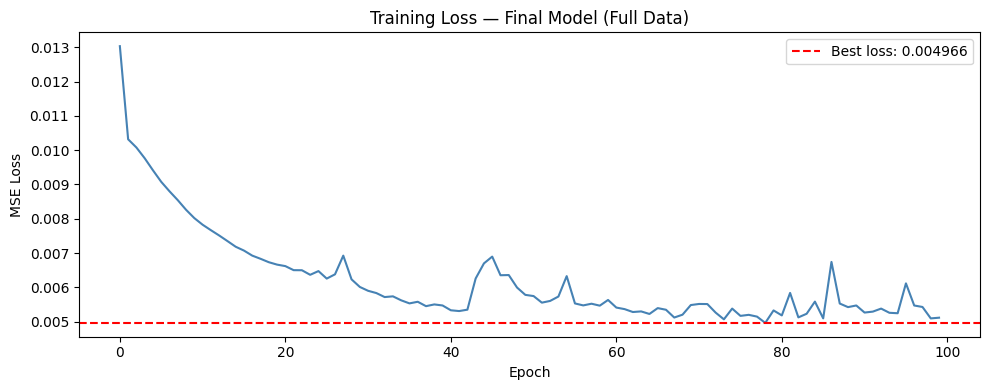

Final training loss: 0.005117
Best training loss:  0.004966


In [9]:
print("Retraining best model on full data for 100 epochs...")

# full data loader for final training
X_full_tensor = torch.tensor(X_train)
full_dataset  = TensorDataset(X_full_tensor)
full_loader   = DataLoader(full_dataset, batch_size=256, shuffle=True)

final_model = LSTMAutoencoder(
    input_size=input_size,
    hidden_size=best_params["hidden_size"],
    num_layers=best_params["num_layers"],
    dropout=best_params["dropout"]
).to(device)

losses = train_model(final_model, full_loader, epochs=100, lr=best_params["lr"], device=device)

# plot training curve
plt.figure(figsize=(10, 4))
plt.plot(losses, color="steelblue")
plt.axhline(min(losses), color="red", linestyle="--", label=f"Best loss: {min(losses):.6f}")
plt.title("Training Loss — Final Model (Full Data)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final training loss: {losses[-1]:.6f}")
print(f"Best training loss:  {min(losses):.6f}")


In [14]:
def get_reconstruction_errors(model, X, batch_size=256):
    errors = []
    dataset = TensorDataset(torch.tensor(X))
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    final_model.eval()
    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(device)
            out = final_model(x)
            error = nn.MSELoss(reduction='none')(out, x).mean(dim=[1,2]).cpu().numpy()
            errors.extend(error)

    return np.array(errors)

# compute threshold per condition
thresholds = {}
train_errors_all = get_reconstruction_errors(final_model, X_train)

for condition in np.unique(cond_train):
    mask = cond_train == condition
    errors = train_errors_all[mask]
    thresholds[condition] = float(np.percentile(errors, 75))
    print(f"Condition {int(condition)} threshold: {thresholds[condition]:.6f}")


Condition 0 threshold: 0.004698
Condition 1 threshold: 0.009156
Condition 2 threshold: 0.009167
Condition 3 threshold: 0.009249
Condition 4 threshold: 0.009183
Condition 5 threshold: 0.009226


Total test engines:  707
Anomalies detected:  190
Anomaly rate:        26.9%


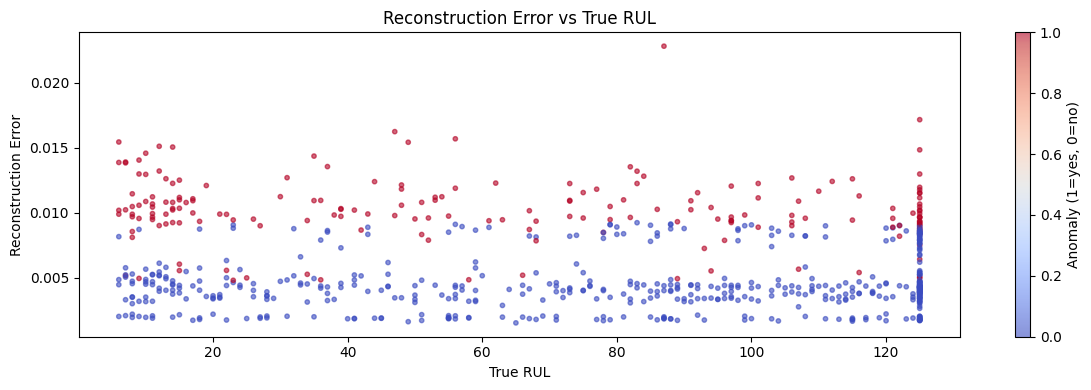

In [15]:
# get test reconstruction errors
test_errors = get_reconstruction_errors(final_model, X_test)

# flag anomalies per condition
anomalies = np.zeros(len(X_test), dtype=bool)
for condition in np.unique(cond_test):
    mask = cond_test == condition
    anomalies[mask] = test_errors[mask] > thresholds[condition]

print(f"Total test engines:  {len(test_errors)}")
print(f"Anomalies detected:  {anomalies.sum()}")
print(f"Anomaly rate:        {anomalies.mean()*100:.1f}%")

# plot reconstruction error vs true RUL
plt.figure(figsize=(12, 4))
plt.scatter(y_test, test_errors, c=anomalies, cmap="coolwarm", s=10, alpha=0.6)
plt.title("Reconstruction Error vs True RUL")
plt.xlabel("True RUL")
plt.ylabel("Reconstruction Error")
plt.colorbar(label="Anomaly (1=yes, 0=no)")
plt.tight_layout()
plt.show()


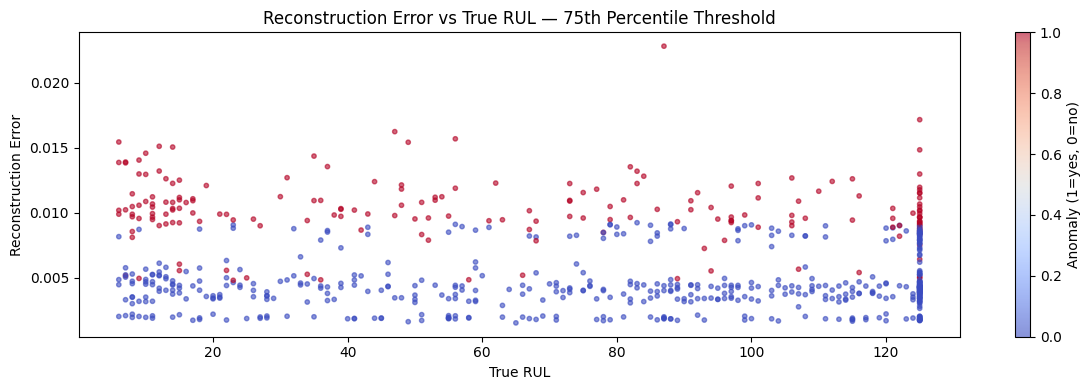

In [16]:
plt.figure(figsize=(12, 4))
plt.scatter(y_test, test_errors, c=anomalies, cmap="coolwarm", s=10, alpha=0.6)
plt.title("Reconstruction Error vs True RUL — 75th Percentile Threshold")
plt.xlabel("True RUL")
plt.ylabel("Reconstruction Error")
plt.colorbar(label="Anomaly (1=yes, 0=no)")
plt.tight_layout()
plt.show()


In [17]:
# split into low vs high RUL
low_rul_mask  = y_test <= 30   # near failure
high_rul_mask = y_test >= 100  # healthy

print(f"Low RUL  (≤30)  — Anomaly rate: {anomalies[low_rul_mask].mean()*100:.1f}%")
print(f"High RUL (≥100) — Anomaly rate: {anomalies[high_rul_mask].mean()*100:.1f}%")


Low RUL  (≤30)  — Anomaly rate: 39.6%
High RUL (≥100) — Anomaly rate: 19.5%


Condition 0 threshold: 0.004698
Condition 1 threshold: 0.009156
Condition 2 threshold: 0.009167
Condition 3 threshold: 0.009249
Condition 4 threshold: 0.009183
Condition 5 threshold: 0.009226

Total test engines:  707
Normal:              517
Suspicious:          109
Critical:            81
Anomaly rate:        26.9%


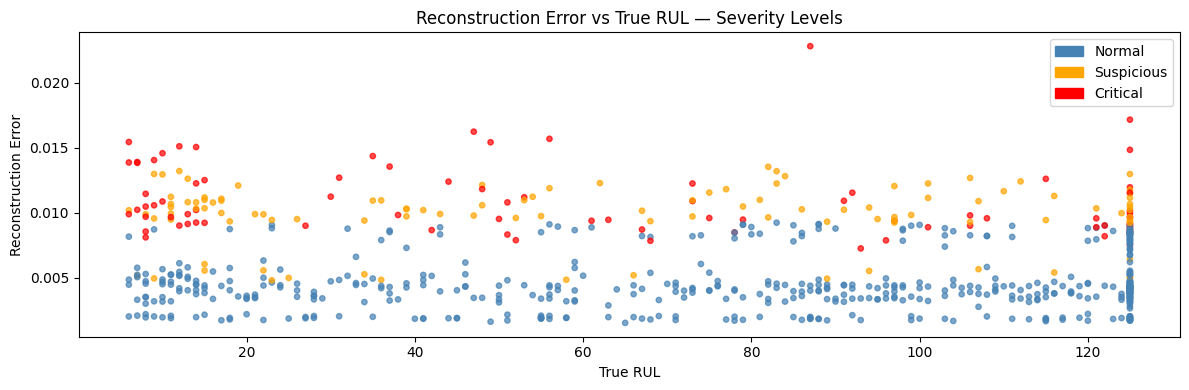


Low RUL  (≤30)  — Anomaly rate: 39.6%
High RUL (≥100) — Anomaly rate: 19.5%


In [18]:
final_model.eval()

def get_reconstruction_errors(model, X, batch_size=256):
    errors = []
    criterion = nn.MSELoss(reduction='none')
    dataset = TensorDataset(torch.tensor(X))
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    model.eval()
    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(device)
            reconstructed = model(x)
            error = criterion(reconstructed, x).mean(dim=[1, 2]).cpu().numpy()
            errors.extend(error)

    return np.array(errors)

# compute errors
train_errors_all = get_reconstruction_errors(final_model, X_train)
test_errors      = get_reconstruction_errors(final_model, X_test)

# per condition threshold (75th percentile)
thresholds = {}
for condition in np.unique(cond_train):
    mask = cond_train == condition
    errors = train_errors_all[mask]
    thresholds[condition] = float(np.percentile(errors, 75))
    print(f"Condition {int(condition)} threshold: {thresholds[condition]:.6f}")

# flag anomalies per condition with 3 severity levels
def get_status(error, threshold):
    if error < threshold:
        return 0  # NORMAL
    elif error < threshold * 1.5:
        return 1  # SUSPICIOUS
    else:
        return 2  # CRITICAL

severity = np.array([
    get_status(test_errors[i], thresholds[cond_test[i]])
    for i in range(len(test_errors))
])

anomalies = severity > 0

print(f"\nTotal test engines:  {len(test_errors)}")
print(f"Normal:              {(severity==0).sum()}")
print(f"Suspicious:          {(severity==1).sum()}")
print(f"Critical:            {(severity==2).sum()}")
print(f"Anomaly rate:        {anomalies.mean()*100:.1f}%")

# plot severity vs true RUL
colors = {0: "steelblue", 1: "orange", 2: "red"}
color_map = [colors[s] for s in severity]

plt.figure(figsize=(12, 4))
plt.scatter(y_test, test_errors, c=color_map, s=15, alpha=0.7)
plt.title("Reconstruction Error vs True RUL — Severity Levels")
plt.xlabel("True RUL")
plt.ylabel("Reconstruction Error")

# legend
from matplotlib.patches import Patch
legend = [
    Patch(color="steelblue", label="Normal"),
    Patch(color="orange",    label="Suspicious"),
    Patch(color="red",       label="Critical")
]
plt.legend(handles=legend)
plt.tight_layout()
plt.show()

# verify low vs high RUL detection
low_rul_mask  = y_test <= 30
high_rul_mask = y_test >= 100
print(f"\nLow RUL  (≤30)  — Anomaly rate: {anomalies[low_rul_mask].mean()*100:.1f}%")
print(f"High RUL (≥100) — Anomaly rate: {anomalies[high_rul_mask].mean()*100:.1f}%")


In [19]:
# check severity distribution for engines at RUL=125
at_cap = y_test == 125
print("At RUL=125:")
print(f"  Normal:     {(severity[at_cap]==0).sum()}")
print(f"  Suspicious: {(severity[at_cap]==1).sum()}")
print(f"  Critical:   {(severity[at_cap]==2).sum()}")

# check severity for low RUL
low = y_test <= 30
print("\nAt RUL≤30:")
print(f"  Normal:     {(severity[low]==0).sum()}")
print(f"  Suspicious: {(severity[low]==1).sum()}")
print(f"  Critical:   {(severity[low]==2).sum()}")


At RUL=125:
  Normal:     121
  Suspicious: 15
  Critical:   14

At RUL≤30:
  Normal:     96
  Suspicious: 35
  Critical:   28


In [20]:
torch.save({
    "model_state_dict" : final_model.state_dict(),
    "best_params"      : best_params,
    "thresholds"       : thresholds,
    "input_size"       : input_size
}, MODELS_DIR / "agent1_autoencoder.pt")

print("Agent 1 saved!")


Agent 1 saved!
